<a href="https://colab.research.google.com/github/JISHANA-T/Depth-from-Stereo/blob/main/Disparity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

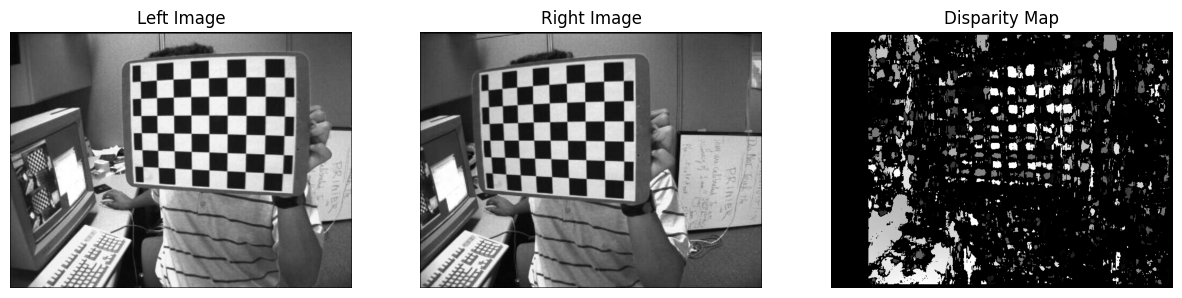

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Download stereo images
urlL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg"
urlR = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/right01.jpg"

urllib.request.urlretrieve(urlL, "left.jpg")
urllib.request.urlretrieve(urlR, "right.jpg")

# Read images
imgL = cv2.imread('left.jpg', 0)
imgR = cv2.imread('right.jpg', 0)

# Create StereoBM object
stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)

# Compute disparity
disparity = stereo.compute(imgL, imgR)

# Normalize for visualization
disparity = cv2.normalize(disparity, None, alpha=0, beta=255,
                          norm_type=cv2.NORM_MINMAX)
disparity = np.uint8(disparity)

# Display
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(imgL, cmap='gray')
plt.title("Left Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imgR, cmap='gray')
plt.title("Right Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(disparity, cmap='gray')
plt.title("Disparity Map")
plt.axis("off")

plt.show()

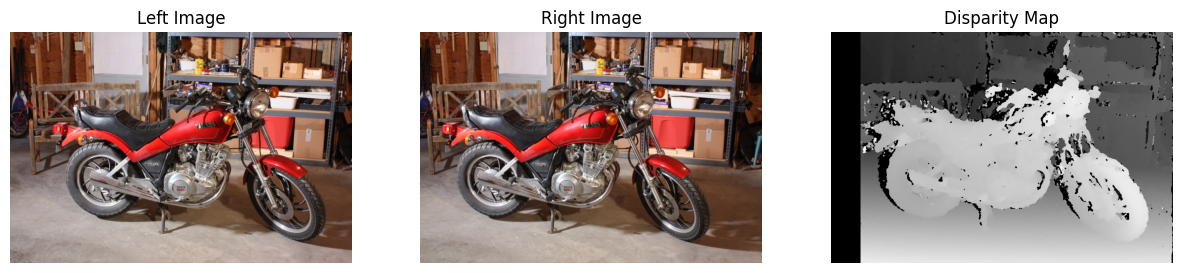

In [ ]:
from skimage import data
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load stereo pair from skimage
stereo_data = data.stereo_motorcycle()

imgL = stereo_data[0]
imgR = stereo_data[1]

# Convert to grayscale
imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

# Create StereoSGBM (better than StereoBM)
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=64,
    blockSize=7
)

disparity = stereo.compute(imgL_gray, imgR_gray)

# Normalize for display
disparity = cv2.normalize(disparity, None, 0, 255,
                          cv2.NORM_MINMAX)
disparity = np.uint8(disparity)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(imgL)
plt.title("Left Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imgR)
plt.title("Right Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(disparity, cmap='gray')
plt.title("Disparity Map")
plt.axis("off")

plt.show()